# PINN example notebook: Logistic Regression

This is an example notebook to learn the basics of Pysics Informed Neural Networks (PINNs) with a very simple example:|
Logistic Regression

The differential equation for logistic regression can be solved analytically. \
Using a neural network to learn this solution to the problem aims to explain the concept and application of a PINN to differential equations in general.

# Import Libraries

In [1]:
import torch 
import torchopt

import matplotlib.pyplot as plt
import torch.optim as optim
import numpy as np

from torch.func import grad, vmap

import torch.nn as nn

# Create a model class

In [14]:
# NNApproximator will be the neural network consisting of an input layer, 
# an output layer, hidden layers in betwee n and tanh as activation function
class NNApproximator(nn.Module):
    def __init__(
        self,
        num_inputs: int = 2,
        num_outputs: int = 2,
        num_hidden: int = 2,
        dim_hidden: int = 2,
        act: nn.Module = nn.Tanh(),
    ) -> None:
        """Simple neural network with linear layers and non-linear activation function
        This class is used as universal function approximator for the solution of
        partial differential equations using PINNs
        Args:
            dim_inputs (int, optional): The number of input dimensions
            dim_outputs (int, optional): The number of outputs of the model, in general is 1
            num_hidden (int, optional): The number of hidden layeim_hidden rs in the model
            dim_hidden (int, optional): The number of neurons for each hidden layer
            act (nn.Module, optional): The type of non-linear activation function to be used
        """
        super().__init__()

        # creates linear input and output layers 
        
        # input layer has num_input inputs neurons and dim_hidden outputs
        self.layer_in = nn.Linear(dim_inputs, dim_hidden)
        # output layer has dim_hidden inputs neurons and num_outputs outputs
        self.layer_out = nn.Linear(dim_hidden, dim_outputs)

        num_middle = num_hidden - 1
        self.middle_layers = nn.ModuleList(
            [nn.Linear(dim_hidden, dim_hidden) for _ in range(num_middle)]
        )
        self.act = act

        self.dim_inputs = dim_inputs
        self.dim_outputs = dim_outputs

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.act(self.layer_in(x))
        for layer in self.middle_layers:
            out = self.act(layer(out))
        return self.layer_out(out)


# Intialisation of the model

In [15]:
# create the PINN model
model = NNApproximator()
# create a dictionary using the parameter names connected with its values
params = dict(model.named_parameters())

# Applying vmap and grad

In [20]:
# Define a function that applies the model to an input vector 
# using the squeeze method to get x into the right form
def apply_model(x):
    
    return model(x.unsqueeze(0)).squeeze(0)

# Apply the model to the input using vmap
model_v = torch.vmap(apply_model)

# computing its derivative using grad 
# important: first apply grad and then use the vmap. You can only grad scalar functions.
diff_model= torch.func.grad(apply_model)
diff_model_v= torch.vmap(diff_model)
diff_diff_model= torch.func.grad(diff_model)
diff_diff_model_v= torch.vmap(diff_diff_model)

# Defining a loss function

In [17]:
R = 1.0  # rate of maximum population growth parameterizing the equation
X_BOUNDARY = 0.0  # boundary condition coordinate
F_BOUNDARY = 0.5  # boundary condition value

# defining a loss function consisting of two parts
# first part calculates the loss in resect to the differential equation
# second parts sets bounday conditions so that the solution converges
def loss_fn(params: torch.Tensor, x: torch.Tensor, model_v) -> torch.Tensor:

    # interior loss
    f_value = model_v(x)
    
    interior = diff_model_v(x)- R * f_value * (1 - f_value)
    

    # boundary loss
    x0 = X_BOUNDARY
    f0 = F_BOUNDARY
    x_boundary = torch.tensor([x0])
    f_boundary = torch.tensor([f0])
    # calculates difference between the the functional value at the boundary and the aimed value
    boundary = model_v(x_boundary)- f_boundary

    # calculates the mean squared error using the nn.MSELoss function
    loss = nn.MSELoss()
    # adding both losses to a total loss
    # the loss function takes its two inputs and calculates the mse of those
    # therefore the second entry is a tensor with the same dimensions but with zeroes 
    loss_value = loss(interior, torch.zeros_like(interior)) + loss(
        boundary, torch.zeros_like(boundary)
    )

    return loss_value

In [ ]:

def loss_fn(model_v, input, g):
    t, v0_x, v0_z = torch.split(input, [1, 1, 1], dim=-1)
    predicted_positions = model(input)
    x_pred, z_pred = torch.split(predicted_positions, [1, 1], dim=-1)
    
    # MSE loss for predicted positions
    mse_loss = F.mse_loss(x_pred, v0_x * t) + F.mse_loss(z_pred, v0_z * t - 0.5 * g * t * t)
    
    # Physics-informed constraint loss
    dzdt_pred = torch.autograd.grad(z_pred, t, create_graph=True)[0]
    d2zdt2_pred = torch.autograd.grad(dzdt_pred, t, create_graph=True)[0]
    physics_loss = F.mse_loss(d2zdt2_pred, -g * torch.ones_like(d2zdt2_pred))
    
    total_loss = mse_loss + physics_loss
    return total_loss


# Training the model

In [18]:
# choose the configuration
batch_size = 30  # number of colocation points sampled in the domain
num_iter =1000 # maximum number of iterations
learning_rate = 1e-3  # learning rate
domain = (-5.0, 5.0)  # logistic equation domain

# choose optimizer with functional API using functorch


#list that keeps track of the loss evolution
loss_evolution = []

# train the model
for i in range(num_iter):

    # sample colocations points in the domain randomly at each epoch
    x = torch.FloatTensor(batch_size).uniform_(domain[0], domain[1])
    output = model_v(x)
    
    #initializing  the optimizer with model parameters
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    # update the parameters using the functional API
    loss = loss_fn(params, x, model_v)
    optimizer.zero_grad()  # Clear the gradients
    loss.backward()  # Compute gradients
    optimizer.step()  # Update the model parameters
    

    print(f"Iteration {i} with loss {float(loss)}")
    
    #appends the loss from every iteration to the loss_evolution list
    loss_evolution.append(float(loss))

# plot solution on the given domain



Iteration 0 with loss 0.30396226048469543
Iteration 1 with loss 0.30276864767074585
Iteration 2 with loss 0.2958804965019226
Iteration 3 with loss 0.29033076763153076
Iteration 4 with loss 0.2870995104312897
Iteration 5 with loss 0.28264373540878296
Iteration 6 with loss 0.27811697125434875
Iteration 7 with loss 0.27725645899772644
Iteration 8 with loss 0.2732722759246826
Iteration 9 with loss 0.2688002586364746
Iteration 10 with loss 0.26309874653816223
Iteration 11 with loss 0.2615513205528259
Iteration 12 with loss 0.25896361470222473
Iteration 13 with loss 0.2523513734340668
Iteration 14 with loss 0.2502700090408325
Iteration 15 with loss 0.2462172508239746
Iteration 16 with loss 0.24159787595272064
Iteration 17 with loss 0.24049556255340576
Iteration 18 with loss 0.23554900288581848
Iteration 19 with loss 0.2335399091243744
Iteration 20 with loss 0.22983339428901672
Iteration 21 with loss 0.2287629395723343
Iteration 22 with loss 0.2229471206665039
Iteration 23 with loss 0.2181481

Iteration 194 with loss 0.0464908741414547
Iteration 195 with loss 0.03982303664088249
Iteration 196 with loss 0.044893529266119
Iteration 197 with loss 0.04171112924814224
Iteration 198 with loss 0.0398574098944664
Iteration 199 with loss 0.04197891801595688
Iteration 200 with loss 0.04480399191379547
Iteration 201 with loss 0.04367572441697121
Iteration 202 with loss 0.04417070373892784
Iteration 203 with loss 0.04395671561360359
Iteration 204 with loss 0.044267844408750534
Iteration 205 with loss 0.043904852122068405
Iteration 206 with loss 0.046000316739082336
Iteration 207 with loss 0.05020497739315033
Iteration 208 with loss 0.04623068869113922
Iteration 209 with loss 0.04337845370173454
Iteration 210 with loss 0.03672327473759651
Iteration 211 with loss 0.046020034700632095
Iteration 212 with loss 0.02793770469725132
Iteration 213 with loss 0.03818420693278313
Iteration 214 with loss 0.04670732840895653
Iteration 215 with loss 0.039964575320482254
Iteration 216 with loss 0.03363

Iteration 386 with loss 0.010443329811096191
Iteration 387 with loss 0.010881761088967323
Iteration 388 with loss 0.0101986825466156
Iteration 389 with loss 0.009651409462094307
Iteration 390 with loss 0.00874815322458744
Iteration 391 with loss 0.00977010652422905
Iteration 392 with loss 0.010038819164037704
Iteration 393 with loss 0.006914238445460796
Iteration 394 with loss 0.010560361668467522
Iteration 395 with loss 0.012286667712032795
Iteration 396 with loss 0.00994682777673006
Iteration 397 with loss 0.00775438267737627
Iteration 398 with loss 0.00824492983520031
Iteration 399 with loss 0.007367535959929228
Iteration 400 with loss 0.00907620694488287
Iteration 401 with loss 0.010016994550824165
Iteration 402 with loss 0.00943558756262064
Iteration 403 with loss 0.009403115138411522
Iteration 404 with loss 0.00939146801829338
Iteration 405 with loss 0.0074981884099543095
Iteration 406 with loss 0.008961709216237068
Iteration 407 with loss 0.007104744669049978
Iteration 408 with 

Iteration 583 with loss 0.00015706980775576085
Iteration 584 with loss 0.0001583109115017578
Iteration 585 with loss 0.0001566794526297599
Iteration 586 with loss 0.0002172443928429857
Iteration 587 with loss 0.00021278033091221005
Iteration 588 with loss 0.00015045050531625748
Iteration 589 with loss 0.00017433408356737345
Iteration 590 with loss 0.00015704231918789446
Iteration 591 with loss 0.00019250049081165344
Iteration 592 with loss 0.00020854882313869894
Iteration 593 with loss 0.00024523859610781074
Iteration 594 with loss 0.0002452394110150635
Iteration 595 with loss 0.0001623890275368467
Iteration 596 with loss 0.00022988603450357914
Iteration 597 with loss 0.0001576816284796223
Iteration 598 with loss 0.0002123610465787351
Iteration 599 with loss 0.0002037676895270124
Iteration 600 with loss 0.00021841969282831997
Iteration 601 with loss 0.00023683474864810705
Iteration 602 with loss 0.0001558799995109439
Iteration 603 with loss 0.00020822435908485204
Iteration 604 with los

Iteration 778 with loss 0.00011091454507550225
Iteration 779 with loss 0.0001135642669396475
Iteration 780 with loss 0.00012164070358267054
Iteration 781 with loss 0.00013181669055484235
Iteration 782 with loss 0.00011353439185768366
Iteration 783 with loss 0.0001103681352105923
Iteration 784 with loss 0.00011373159213690087
Iteration 785 with loss 0.00012151616101618856
Iteration 786 with loss 6.92966568749398e-05
Iteration 787 with loss 0.00010958674101857468
Iteration 788 with loss 0.00013993824541103095
Iteration 789 with loss 9.202573710354045e-05
Iteration 790 with loss 0.00011718551104422659
Iteration 791 with loss 9.259485523216426e-05
Iteration 792 with loss 0.00011871461902046576
Iteration 793 with loss 8.79464132594876e-05
Iteration 794 with loss 0.00013239144755061716
Iteration 795 with loss 0.000109458553197328
Iteration 796 with loss 0.00010723928426159546
Iteration 797 with loss 7.448605174431577e-05
Iteration 798 with loss 7.598249067086726e-05
Iteration 799 with loss 9

Iteration 962 with loss 6.0855094488942996e-05
Iteration 963 with loss 9.032317757373676e-05
Iteration 964 with loss 7.679891132283956e-05
Iteration 965 with loss 8.656499267090112e-05
Iteration 966 with loss 5.2466042689047754e-05
Iteration 967 with loss 8.126283501042053e-05
Iteration 968 with loss 0.00010157910583075136
Iteration 969 with loss 7.534702308475971e-05
Iteration 970 with loss 6.475411646533757e-05
Iteration 971 with loss 0.00011220460874028504
Iteration 972 with loss 8.128306944854558e-05
Iteration 973 with loss 5.084850999992341e-05
Iteration 974 with loss 5.4789288697065786e-05
Iteration 975 with loss 7.454030128428712e-05
Iteration 976 with loss 8.249644452007487e-05
Iteration 977 with loss 6.514499546028674e-05
Iteration 978 with loss 7.078242197167128e-05
Iteration 979 with loss 9.548530942993239e-05
Iteration 980 with loss 7.945385004859418e-05
Iteration 981 with loss 8.783014345681295e-05
Iteration 982 with loss 8.340971544384956e-05
Iteration 983 with loss 5.541

# Plotting the solution and the loss evolution

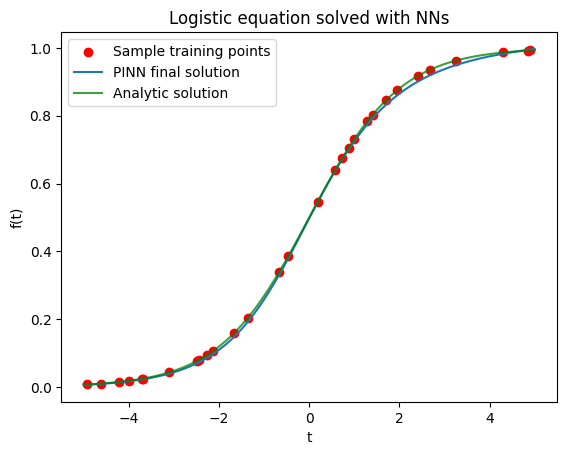

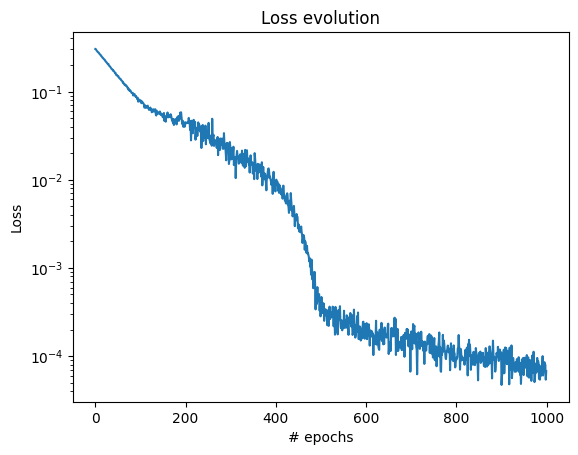

In [19]:
# creates list, with entries between 0 and 1 in 100 steps. 
# reshape brings it in form of a vector 
# -1 => the vector has as many rows as entries
# 1 => the vector has one column
x_eval = torch.linspace(domain[0], domain[1], steps=100).reshape(-1, 1)

# evaluates the function values to the given x values
f_eval = model_v(x_eval).squeeze()

# creates a analytical solution for comparison purposes
analytical_sol_fn = lambda x: 1.0 / (1.0 + (1.0/F_BOUNDARY - 1.0) * np.exp(-R * x))

# creates a numpy array from x_eval and detaches it from x_eval
x_eval_np = x_eval.detach().numpy()

# creates an numpy array with the x values of the sample points
x_sample_np = torch.FloatTensor(batch_size).uniform_(domain[0], domain[1]).detach().numpy()

#creates Figures and axes for the first plot

fig, ax = plt.subplots()

# creates a scatter plot of the Sample training points
ax.scatter(x_sample_np, analytical_sol_fn(x_sample_np), color="red", label="Sample training points")
# ads the PINN solution, analytical solution, title and legend to the plot
ax.plot(x_eval_np, f_eval.detach().numpy(), label="PINN final solution")
ax.plot(
    x_eval_np,
    analytical_sol_fn(x_eval_np),
    label=f"Analytic solution",
    color="green",
    alpha=0.75,
)
ax.set(title="Logistic equation solved with NNs", xlabel="t", ylabel="f(t)")
ax.legend()

#creates Figures and axes for the second plot
fig, ax = plt.subplots()
ax.semilogy(loss_evolution) #y-axis is logarithmic
ax.set(title="Loss evolution", xlabel="# epochs", ylabel="Loss")


plt.show()

# runge kutta data generation


[[  0.          40.           0.          60.        ]
 [  0.39590631  39.18698245   0.5933723   58.68337045]
 [  0.78385054  38.40724045   1.17384011  57.41856542]
 ...
 [ 57.42350875   0.23811987 -82.8110057  -18.44520165]
 [ 57.42588364   0.23685871 -82.99545846 -18.44535033]
 [ 57.42824594   0.23560423 -83.1799127  -18.44549753]]
[ 0.    0.01  0.02 ...  9.98  9.99 10.  ]


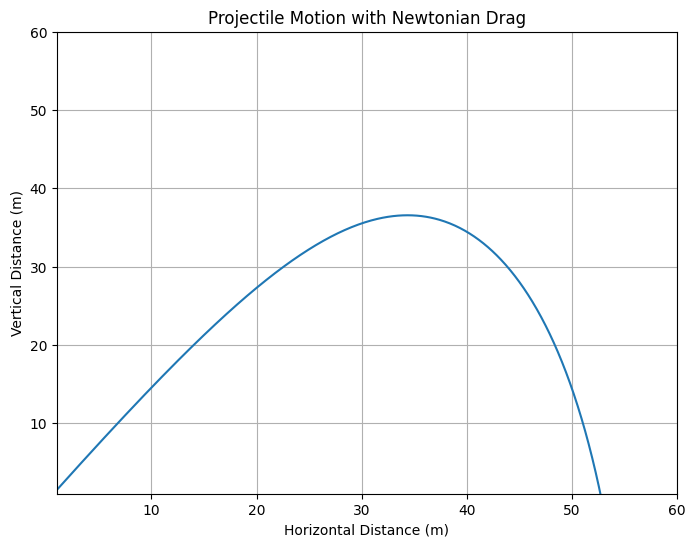

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def runge_kutta_4th_order(f, x0, y0, h, n):
    """
    Fourth-order Runge-Kutta method for solving a system of first-order ODEs.

    Parameters:
    f: Function that defines the system of ODEs.
    x0: Initial x value.
    y0: Initial y value (initial conditions).
    h: Step size.
    n: Number of steps.

    Returns:
    x_vals: Array of x values.
    y_vals: Array of y values.
    """
    x_vals = [x0]
    y_vals = [y0]

    for _ in range(n):
        k1 = h * f(x_vals[-1], y_vals[-1])
        k2 = h * f(x_vals[-1] + h / 2, y_vals[-1] + k1 / 2)
        k3 = h * f(x_vals[-1] + h / 2, y_vals[-1] + k2 / 2)
        k4 = h * f(x_vals[-1] + h, y_vals[-1] + k3)

        x_vals.append(x_vals[-1] + h)
        y_vals.append(y_vals[-1] + (k1 + 2 * k2 + 2 * k3 + k4) / 6)

    return np.array(x_vals), np.array(y_vals)

def projectile_motion_with_drag(t, u):
    """
    System of ODEs describing projectile motion with Newtonian drag.

    Parameters:
    t: Time variable (not used, as motion is only in x-direction).
    u: 1D array containing [x, vx, y, vy] (position and velocity components).

    Returns:
    dudt: Derivative of u with respect to t.
    """
    x, vx, y, vy = u
    g = 9.81  # Acceleration due to gravity (m/s^2)
    rho = 1.225  # Air density (kg/m^3)
    Cd = 0.47  # Drag coefficient
    A = 0.01  # Cross-sectional area (m^2)
    m = 0.1  # Mass of the projectile (kg)

    v = np.sqrt(vx**2 + vy**2)
    Fx = -0.5 * rho * Cd * A * v * vx
    Fy = -0.5 * rho * Cd * A * v * vy

    dxdt = vx
    dvxdt = (Fx / m)
    dydt = vy
    dvydt = (Fy / m) - g

    return np.array([dxdt, dvxdt, dydt, dvydt])

# Initial conditions
x0 = 0.0
y0 = 0.0
vx0 = 40.0
vy0 = 60.0

u0 = np.array([x0, vx0, y0, vy0])

# Time settings
t0 = 0.0
h = 0.01  # Step size
num_steps = 1000

# Solve the system of ODEs using Runge-Kutta 4th order
time_vals, state_vals = runge_kutta_4th_order(projectile_motion_with_drag, t0, u0, h, num_steps)

# Extract position values
x_vals = state_vals[:, 0]
y_vals = state_vals[:, 2]
print(state_vals)
print(time_vals)

# Plot the trajectory
plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals)
plt.title("Projectile Motion with Newtonian Drag")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Vertical Distance (m)")
# Set x and y axis ranges
plt.xlim(1, 60)  # Adjust the range for x-axis
plt.ylim(1, 60)  # Adjust the range for y-axis
plt.grid(True)
plt.show()


Epoch [1000/10000], Loss: 9.4869
Epoch [2000/10000], Loss: 4.0976
Epoch [3000/10000], Loss: 3.8616
Epoch [4000/10000], Loss: 2.8326
Epoch [5000/10000], Loss: 0.6854
Epoch [6000/10000], Loss: 0.6843
Epoch [7000/10000], Loss: 0.6843
Epoch [8000/10000], Loss: 0.6843
Epoch [9000/10000], Loss: 0.6843
Epoch [10000/10000], Loss: 0.6843


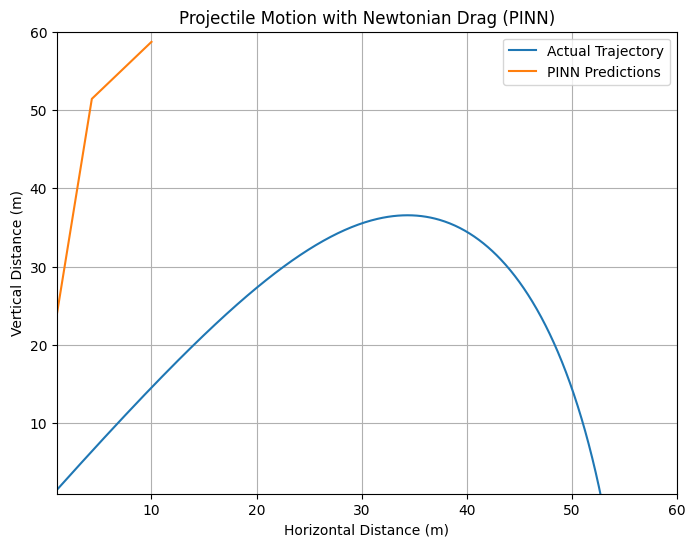

In [47]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Generate data using the provided Runge-Kutta solver
# ... (Your data generation code here)

# Convert numpy arrays to PyTorch tensors
x_data = torch.tensor(time_vals, dtype=torch.float32).view(-1, 1)
y_data = torch.tensor(state_vals[:, 0:2], dtype=torch.float32)  # We'll predict x and vx

# Define the Physics-Informed Neural Network (PINN) architecture
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.fc1 = nn.Linear(1, 30)
        self.fc2 = nn.Linear(30, 30)
        self.fc3 = nn.Linear(30, 2)  # Predict x and vx

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Instantiate the PINN model
pinn_model = PINN()

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(pinn_model.parameters(), lr=0.001)
# Define a function that applies the model to an input vector 
# using the squeeze method to get x into the right form
def apply_model(x):
    
    return pinn_model(x.unsqueeze(0)).squeeze(0)

# Apply the model to the input using vmap
model_v = torch.vmap(apply_model)

# computing its derivative using grad 
# important: first apply grad and then use the vmap. You can only grad scalar functions.
diff_model= torch.func.grad(apply_model)
diff_model_v= torch.vmap(diff_model)
diff_diff_model= torch.func.grad(diff_model)
diff_diff_model_v= torch.vmap(diff_diff_model)
# Training loop
num_epochs = 10000
for epoch in range(num_epochs):
    # Zero the gradients
    optimizer.zero_grad()
    
    # Forward pass
    outputs = model_v(x_data)
    
    # Compute the loss
    loss = criterion(outputs, y_data)
    
    # Backpropagation and optimization
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Generate predictions using the trained PINN model
x_pred = torch.linspace(0, max(time_vals), 1000).view(-1, 1)
with torch.no_grad():
    y_pred = pinn_model(x_pred)

# Plot the trajectory and PINN predictions
plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, label='Actual Trajectory')
plt.plot(x_pred, y_pred[:, 0], label='PINN Predictions')
plt.title("Projectile Motion with Newtonian Drag (PINN)")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Vertical Distance (m)")
plt.xlim(1, 60)
plt.ylim(1, 60)
plt.legend()
plt.grid(True)
plt.show()
